# TrashNet Inference
Evaluate BinVision saved models on the TrashNet dataset.

**Recyclable (1):** cardboard, glass, metal, paper, plastic

**Non-recyclable (0):** trash

In [1]:
import os, json, joblib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
TRASHNET_DIR = Path("dataset-resized")
TRASH = {"trash"}
with open("saved/preprocessing_config.json") as f:
    cfg = json.load(f)
IMG_SIZE = tuple(cfg["cnn_img_size"])
EN_SIZE  = cfg["en_img_size"][0]
MEAN     = cfg["imagenet_mean"]
STD      = cfg["imagenet_std"]
print("IMG_SIZE:", IMG_SIZE, "  EN_SIZE:", EN_SIZE)
for d in sorted(TRASHNET_DIR.iterdir()):
    if d.is_dir():
        label = 0 if d.name in TRASH else 1
        n = len(list(d.glob("*.jpg")))
        print(f"  {d.name:<12} {n} images -> label {label}")


IMG_SIZE: (128, 128)   EN_SIZE: 224
  cardboard    403 images -> label 1
  glass        501 images -> label 1
  metal        410 images -> label 1
  paper        594 images -> label 1
  plastic      482 images -> label 1
  trash        137 images -> label 0


### Flat features for sklearn models

In [3]:
def load_flat(root, img_size):
    X, y = [], []
    for cls_dir in sorted(root.iterdir()):
        if not cls_dir.is_dir():
            continue
        label = 0 if cls_dir.name in TRASH else 1
        for f in sorted(cls_dir.glob("*.jpg")):
            try:
                img = Image.open(f).convert("RGB").resize(img_size)
                X.append(np.array(img).flatten() / 255.0)
                y.append(label)
            except Exception:
                pass
    return np.array(X), np.array(y)

print("Loading flat features...")
X_flat, y_flat = load_flat(TRASHNET_DIR, IMG_SIZE)
print(f"Shape: {X_flat.shape}")
print(f"Recyclable: {(y_flat==1).sum()}   Non-recyclable: {(y_flat==0).sum()}")

Loading flat features...
Shape: (2527, 49152)
Recyclable: 2390   Non-recyclable: 137


### PyTorch DataLoaders

In [4]:
class TrashNetDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        for cls_dir in sorted(Path(root).iterdir()):
            if not cls_dir.is_dir():
                continue
            label = 0 if cls_dir.name in TRASH else 1
            for f in sorted(cls_dir.glob("*.jpg")):
                self.samples.append((str(f), label))
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert("RGB")), label

cnn_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
en_tf = transforms.Compose([
    transforms.Resize((EN_SIZE, EN_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
cnn_loader = DataLoader(TrashNetDataset(TRASHNET_DIR, cnn_tf), batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
en_loader  = DataLoader(TrashNetDataset(TRASHNET_DIR, en_tf),  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
print(f"Loaded {len(cnn_loader.dataset)} images")

Loaded 2527 images


### Load saved models

In [5]:
lr_model = joblib.load("saved/lr_model.joblib")
rf_model = joblib.load("saved/rf_model.joblib")
svm_pipe = joblib.load("saved/svm_pipe.joblib")
print("Loaded: LR, RF, SVM")

Loaded: LR, RF, SVM


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128, 2),
        )
    def forward(self, x):
        return self.head(self.features(x))

ckpt = torch.load("saved/cnn_best.pt", map_location=DEVICE)
cnn_model = SimpleCNN().to(DEVICE)
cnn_model.load_state_dict(ckpt["state_dict"])
cnn_model.eval()
print("Loaded: CNN")

Loaded: CNN


C:\Users\notdu\AppData\Local\Temp\ipykernel_20816\1552153171.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("saved/cnn_best.pt", map_location=DEVICE)

In [7]:
en_model = models.efficientnet_b0(weights=None)
en_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(en_model.classifier[1].in_features, 2),
)
ckpt_en = torch.load("saved/efficientnet_best.pt", map_location=DEVICE)
en_model.load_state_dict(ckpt_en["state_dict"])
en_model = en_model.to(DEVICE)
en_model.eval()
print("Loaded: EfficientNet-B0")

Loaded: EfficientNet-B0


C:\Users\notdu\AppData\Local\Temp\ipykernel_20816\2428088999.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_en = torch.load("saved/efficientnet_best.pt", map_locat

### Run inference

In [8]:
def predict_torch(model, loader, device):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for X, y in loader:
            out = model(X.to(device))
            p   = torch.softmax(out, 1)
            preds.extend(out.argmax(1).cpu().numpy())
            probs.extend(p[:, 1].cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(probs), np.array(labels)

print("Running sklearn models...")
y_pred_lr  = lr_model.predict(X_flat);  y_prob_lr  = lr_model.predict_proba(X_flat)[:, 1]
y_pred_rf  = rf_model.predict(X_flat);  y_prob_rf  = rf_model.predict_proba(X_flat)[:, 1]
y_pred_svm = svm_pipe.predict(X_flat);  y_prob_svm = svm_pipe.predict_proba(X_flat)[:, 1]
print("Running CNN...")
y_pred_cnn, y_prob_cnn, y_true_cnn = predict_torch(cnn_model, cnn_loader, DEVICE)
print("Running EfficientNet...")
y_pred_en, y_prob_en, y_true_en = predict_torch(en_model, en_loader, DEVICE)
print("Done.")

Running sklearn models...
Running CNN...
Running EfficientNet...
Done.


### Results

In [9]:
results = [
    ("Logistic Regression",  y_pred_lr,  y_prob_lr,  y_flat),
    ("Random Forest",        y_pred_rf,  y_prob_rf,  y_flat),
    ("SVM (PCA+LinearSVC)",  y_pred_svm, y_prob_svm, y_flat),
    ("Custom CNN",           y_pred_cnn, y_prob_cnn, y_true_cnn),
    ("EfficientNet-B0",      y_pred_en,  y_prob_en,  y_true_en),
]

for name, preds, probs, labels in results:
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")

Logistic Regression           0.6458     0.7747     0.7001
Random Forest                 0.6292     0.7643     0.6211
SVM (PCA+LinearSVC)           0.6549     0.7811     0.7253
Custom CNN                    0.8045     0.8896     0.6452
EfficientNet-B0               0.8829     0.9368     0.6708


In [10]:
for name, preds, _, labels in results:
    print()
    print(f"{name}")
    print(classification_report(labels, preds,
          target_names=["Non-recyclable", "Recyclable"], zero_division=0))


Logistic Regression
                precision    recall  f1-score   support

Non-recyclable       0.10      0.68      0.17       137
    Recyclable       0.97      0.64      0.77      2390

      accuracy                           0.65      2527
     macro avg       0.54      0.66      0.47      2527
  weighted avg       0.92      0.65      0.74      2527


Random Forest
                precision    recall  f1-score   support

Non-recyclable       0.08      0.52      0.13       137
    Recyclable       0.96      0.64      0.76      2390

      accuracy                           0.63      2527
     macro avg       0.52      0.58      0.45      2527
  weighted avg       0.91      0.63      0.73      2527


SVM (PCA+LinearSVC)
                precision    recall  f1-score   support

Non-recyclable       0.11      0.72      0.19       137
    Recyclable       0.98      0.65      0.78      2390

      accuracy                           0.65      2527
     macro avg       0.54      0.69    

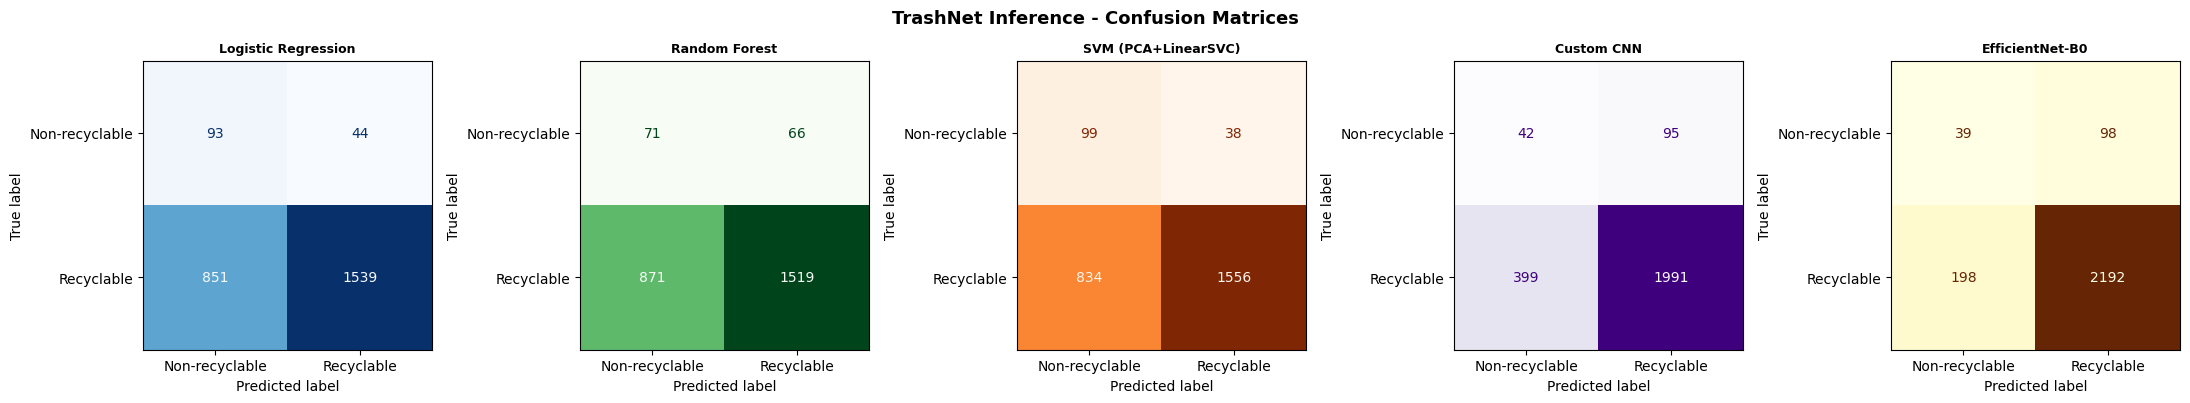

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
cmaps = ["Blues", "Greens", "Oranges", "Purples", "YlOrBr"]
for ax, (name, preds, _, labels), cmap in zip(axes, results, cmaps):
    ConfusionMatrixDisplay(confusion_matrix(labels, preds),
                           display_labels=["Non-recyclable", "Recyclable"]).plot(
                           ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=9, fontweight="bold")
plt.suptitle("TrashNet Inference - Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("trashnet_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

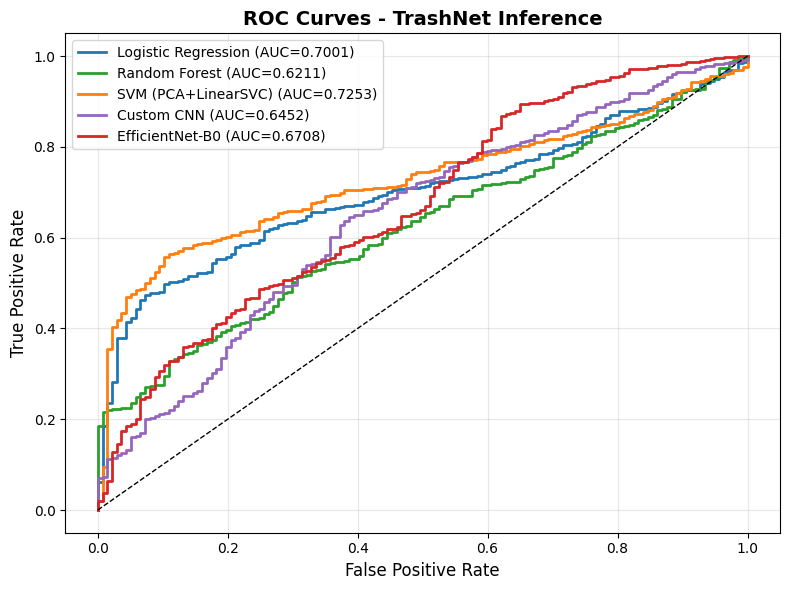

In [12]:
colors_roc = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#d62728"]
fig, ax = plt.subplots(figsize=(8, 6))
for (name, preds, probs, labels), color in zip(results, colors_roc):
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(labels, probs):.4f})",
            color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves - TrashNet Inference", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("trashnet_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()